In [9]:
# %conda install matplotlib
# %conda install seaborn
import pandas as pd, matplotlib.pyplot as plt, seaborn as sns
import scipy.stats as stats

url = "https://raw.githubusercontent.com/nkmwicz/data-for-students/refs/heads/main/soccer-players.csv"

df = pd.read_csv(url)
df.columns

Index(['player_id', 'first_name', 'last_name', 'name', 'last_season',
       'current_club_id', 'player_code', 'country_of_birth', 'city_of_birth',
       'country_of_citizenship', 'date_of_birth', 'sub_position', 'position',
       'foot', 'height_in_cm', 'contract_expiration_date', 'agent_name',
       'image_url', 'url', 'current_club_domestic_competition_id',
       'current_club_name', 'market_value_in_eur',
       'highest_market_value_in_eur'],
      dtype='str')

In [10]:
df.sample(18)

,player_id,first_name,last_name,name,last_season,current_club_id,player_code,country_of_birth,city_of_birth,country_of_citizenship,...,foot,height_in_cm,contract_expiration_date,agent_name,image_url,url,current_club_domestic_competition_id,current_club_name,market_value_in_eur,highest_market_value_in_eur
23705,499956,Mathieu,De Smet,Mathieu De Smet,2021,3508,mathieu-de-smet,Belgium,Maldegem,Belgium,...,left,NaN,2023-06-30 00:00:00,NaN,https://img.a.transfermarkt.technology/portrai...,https://www.transfermarkt.co.uk/mathieu-de-sme...,BE1,SV Zulte Waregem,200000.0,400000.0
6648,79209,Sergey,Chepchugov,Sergey Chepchugov,2016,2410,sergey-chepchugov,UdSSR,Krasnoyarsk,Russia,...,right,186.0,NaN,NaN,https://img.a.transfermarkt.technology/portrai...,https://www.transfermarkt.co.uk/sergey-chepchu...,RU1,PFK CSKA Moskva,25000.0,800000.0
9283,129971,Dale,Carrick,Dale Carrick,2015,2553,dale-carrick,Scotland,Edinburgh,Scotland,...,right,180.0,2023-05-31 00:00:00,NaN,https://img.a.transfermarkt.technology/portrai...,https://www.transfermarkt.co.uk/dale-carrick/p...,SC1,Kilmarnock Football Club,150000.0,175000.0
21198,402893,Vangelis,Theocharis,Vangelis Theocharis,2021,265,vangelis-theocharis,Greece,Livadia,Greece,...,right,181.0,2023-06-30 00:00:00,FAIR FOOTBALL AGENCY,https://img.a.transfermarkt.technology/portrai...,https://www.transfermarkt.co.uk/vangelis-theoc...,GR1,Panathinaikos Athlitikos Omilos,200000.0,300000.0
26142,599677,Mads,Winther,Mads Winther,2021,5817,mads-winther,Denmark,Sønderborg,Denmark,...,right,192.0,NaN,NaN,https://img.a.transfermarkt.technology/portrai...,https://www.transfermarkt.co.uk/mads-winther/p...,DK1,Sønderjyske Fodbold,150000.0,150000.0
30127,849410,Valentín,Barco,Valentín Barco,2024,368,valentin-barco,Argentina,25 de Mayo,Argentina,...,left,170.0,2025-06-30 00:00:00,NaN,https://img.a.transfermarkt.technology/portrai...,https://www.transfermarkt.co.uk/valentin-barco...,ES1,Sevilla Fútbol Club S.A.D.,10000000.0,13000000.0
12261,194218,Yeltsin,Tejeda,Yeltsin Tejeda,2014,14171,yeltsin-tejeda,Costa Rica,Puerto Limón,Costa Rica,...,right,179.0,2023-06-30 00:00:00,B.C Football Agency,https://img.a.transfermarkt.technology/portrai...,https://www.transfermarkt.co.uk/yeltsin-tejeda...,FR1,Thonon Évian Grand Genève FC,275000.0,1500000.0
26057,596097,Alexandros,Chalatsis,Alexandros Chalatsis,2020,4603,alexandros-chalatsis,NaN,NaN,Greece,...,right,189.0,2023-06-30 00:00:00,NaN,https://img.a.transfermarkt.technology/portrai...,https://www.transfermarkt.co.uk/alexandros-cha...,GR1,AE Larisa,50000.0,50000.0
15648,268176,Sergi,Palencia,Sergi Palencia,2019,618,sergi-palencia,Spain,Badalona,Spain,...,right,172.0,2024-12-31 00:00:00,AC Talent,https://img.a.transfermarkt.technology/portrai...,https://www.transfermarkt.co.uk/sergi-palencia...,FR1,Association sportive de Saint-Étienne Loire,2000000.0,6000000.0
20956,396869,Germán,Rivero,Germán Rivero,2018,441,german-rivero,Argentina,Garín,Argentina,...,right,182.0,2023-12-31 00:00:00,Score Futbol,https://img.a.transfermarkt.technology/portrai...,https://www.transfermarkt.co.uk/german-rivero/...,GR1,Apollon Smyrnis,250000.0,650000.0


In [11]:
df = df[["name","position", "date_of_birth", "height_in_cm"]]

In [12]:
df.head()

,name,position,date_of_birth,height_in_cm
0,Miroslav Klose,Attack,1978-06-09 00:00:00,184.0
1,Roman Weidenfeller,Goalkeeper,1980-08-06 00:00:00,190.0
2,Dimitar Berbatov,Attack,1981-01-30 00:00:00,NaN
3,Lúcio,Defender,1978-05-08 00:00:00,NaN
4,Tom Starke,Goalkeeper,1981-03-18 00:00:00,194.0


In [13]:
df["month"] = pd.to_datetime(df["date_of_birth"]).dt.month
df.head()

,name,position,date_of_birth,height_in_cm,month
0,Miroslav Klose,Attack,1978-06-09 00:00:00,184.0,6.0
1,Roman Weidenfeller,Goalkeeper,1980-08-06 00:00:00,190.0,8.0
2,Dimitar Berbatov,Attack,1981-01-30 00:00:00,NaN,1.0
3,Lúcio,Defender,1978-05-08 00:00:00,NaN,5.0
4,Tom Starke,Goalkeeper,1981-03-18 00:00:00,194.0,3.0


In [14]:
df = df.dropna(subset=["height_in_cm"])
df = df.loc[df["height_in_cm"] > 150]
df.head()

,name,position,date_of_birth,height_in_cm,month
0,Miroslav Klose,Attack,1978-06-09 00:00:00,184.0,6.0
1,Roman Weidenfeller,Goalkeeper,1980-08-06 00:00:00,190.0,8.0
4,Tom Starke,Goalkeeper,1981-03-18 00:00:00,194.0,3.0
7,Tomas Rosicky,Midfield,1980-10-04 00:00:00,179.0,10.0
8,Marc Ziegler,Goalkeeper,1976-06-13 00:00:00,193.0,6.0


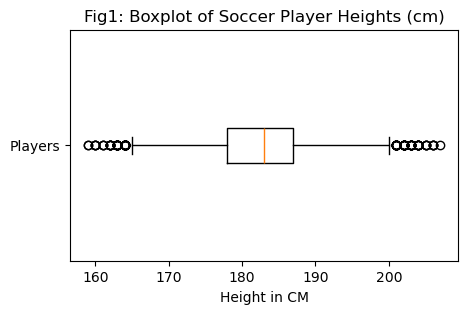

In [21]:
plt.figure(figsize=(5,3))
plt.boxplot(x=df["height_in_cm"], orientation="horizontal")
plt.title("Fig1: Boxplot of Soccer Player Heights (cm)")
plt.xlabel("Height in CM")
plt.yticks(ticks=[1], labels=["Players"])
plt.show()

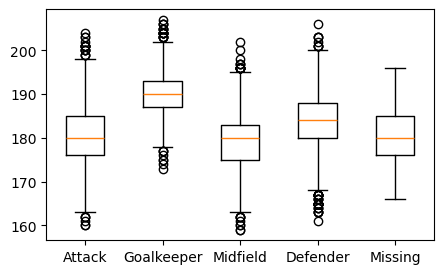

In [26]:
plt.figure(figsize=(5,3))
pos = df["position"].unique()
data = [df.loc[df["position"] == p, "height_in_cm"] for p in pos]
plt.boxplot(x=data)
plt.xticks(ticks=range(1,len(pos)+1), labels=pos)
plt.show()

In [32]:
def boxplots(df:pd.DataFrame, y:str, x:str, title:str="", ylabel: str=""):
    plt.figure(figsize=(5,3))
    hts_box = sns.boxplot(data=df, y=y, x=x)
    hts_box.set(
        title=title,
        ylabel=ylabel)
    plt.axhline(df[y].mean(), label="Mean", linestyle="--", color="red")
    plt.legend()
    plt.show()

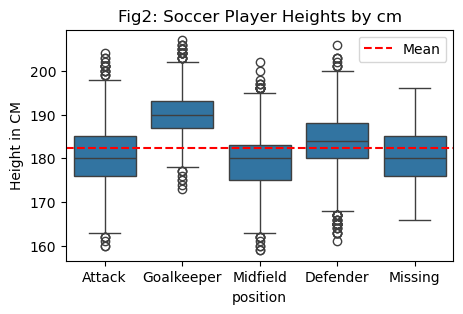

In [33]:
boxplots(df=df, x="position", y="height_in_cm", title="Fig2: Soccer Player Heights by cm", ylabel="Height in CM")

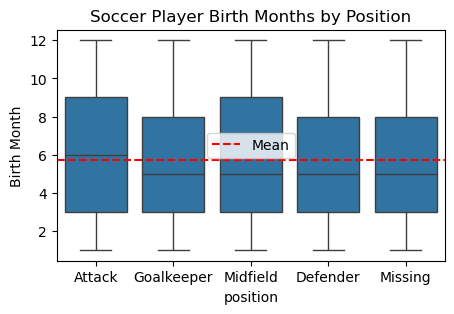

In [34]:
boxplots(df=df, x="position", y="month", title="Soccer Player Birth Months by Position", ylabel="Birth Month")

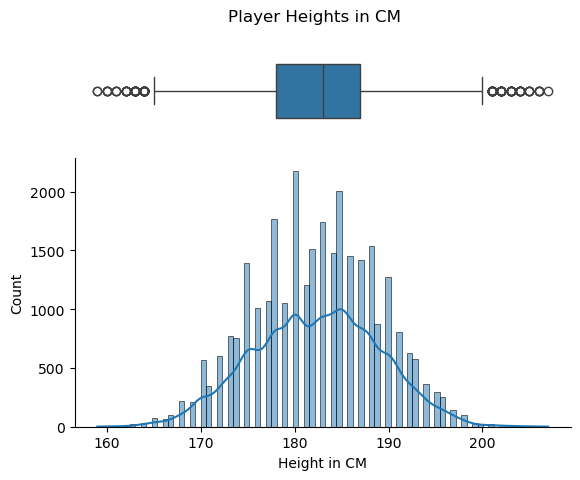

In [ ]:
def generate_multiplot(df:pd.DataFrame, col:str, xlabel:str="", title:str=""):
    fig, (ax1, ax2) = plt.subplots(nrows=2, ncols=1, height_ratios=[2,8])
    box = sns.boxplot(data=df, x=col, ax=ax1)
    hist = sns.histplot(data=df, x=col, ax=ax2, kde=True)
    box.set(yticks=[], xticks=[], xlabel="")
    hist.set(xlabel=xlabel)
    ax1.spines["bottom"].set_visible(False)
    ax1.spines["top"].set_visible(False)
    ax1.spines["right"].set_visible(False)
    ax1.spines["left"].set_visible(False)
    ax2.spines["right"].set_visible(False)
    ax2.spines["top"].set_visible(False)
    fig.suptitle(title)

generate_multiplot(df=df, col="height_in_cm", xlabel="Height in CM", title="Player Heights in CM")

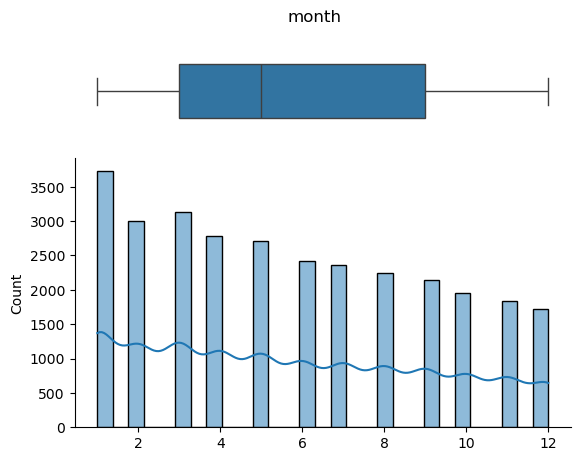

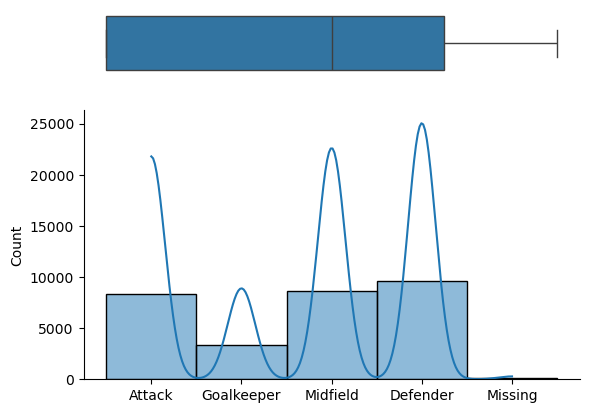

In [50]:
generate_multiplot(df=df, col="month", title="month")
generate_multiplot(df=df, col="position")